# This data was generated by calling the API
Every request was the same summary (same content score)
A random score history was provided

In [1]:
import random
from pathlib import Path
from collections import defaultdict
import itertools as it
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from conjugate_normal import conjugate_normal

In [3]:
df1 = pd.read_json("fake_summary_scores.jsonl", lines=True)
df2 = pd.json_normalize(df1["metrics"], sep="_")
df = pd.concat([
    df1,
    df2,
], axis=1)
df = df.dropna(subset=["content_score"])
print(len(df))
display(df.sample(1))

50


,is_passed,prompt,metrics,score_history,containment_name,containment_is_passed,containment_score,containment_threshold,containment_feedback,containment_chat_name,...,english_name,english_is_passed,english_score,english_threshold,english_feedback,profanity_name,profanity_is_passed,profanity_score,profanity_threshold,profanity_feedback
33,True,Excellent job summarizing the text. Please mov...,"{'containment': {'name': 'Language Borrowing',...","[0.040520765940423004, 0.510309550161514, 0.47...",Language Borrowing,True,0.0,0.6,You did a good job of using your own language ...,Language Borrowing (from iTELL AI),...,English,True,1.0,1.0,,Profanity,True,0.0,0.0,


In [4]:
mu_global = 0.8
k_global = 15
alpha_global = 4
beta_global = 1

k_volume = 3

In [5]:
volumes = {}
volume_updates = []
submission_threshold = []

volume = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=0.2)
start_threshold = volume.threshold

student_score_history = defaultdict(list)

for i, row in enumerate(df.itertuples()):
    # Create temporary volume prior from volume prior information
    student_dist = conjugate_normal(volume.mu, k_volume, volume.alpha, volume.beta, percentile=0.2)

    # Update temporary volume prior with score history
    if row.score_history:
        student_dist.update(row.score_history)
        # Record threshold
        submission_threshold.append(student_dist.threshold)
    else:
        submission_threshold.append(volume.threshold)

    volume.update([row.content_score])
    volume_updates.append((volume.mu, volume.sigma, volume.threshold))

    
df["bayesian_threshold"] = submission_threshold

,Observed,Simulated Bayesian Personalized,20th Percentile
0,0.76,0.76,0.0


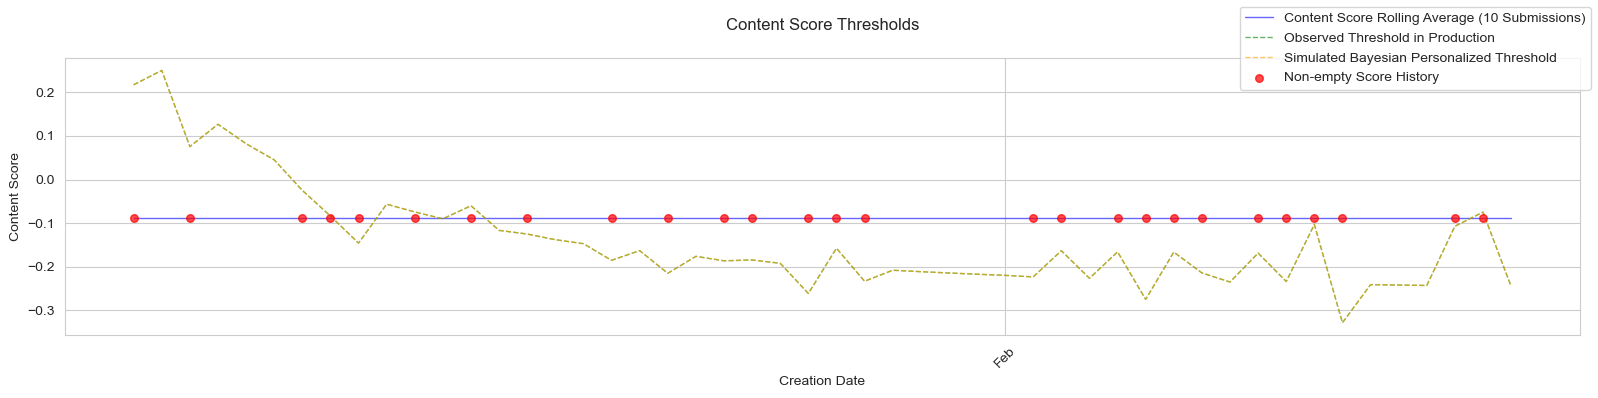

In [6]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(16, 4))

pass_rates = []

# Calculate and plot rolling average (10 submissions)
rolling_avg = df['content_score'].rolling(window=10, min_periods=1).mean()
sns.lineplot(ax=ax, x=df.index, y=rolling_avg, 
             label='Content Score Rolling Average (10 Submissions)', legend=False,
             color='blue', linewidth=1, alpha=0.6)

# Draw Observed Threshold (as the student experienced it)
sns.lineplot(ax=ax, data=df, x=df.index, y='content_threshold', 
             label='Observed Threshold in Production', legend=False,
             color='green', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Volume Prior
# updates_array = np.array(volume_updates)
# sns.lineplot(ax=ax, x=df.index, y=updates_array[:,2], 
#              label='Simulated Bayesian Volume Prior Threshold', legend=False,
#              color='purple', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Bayesian Threshold
sns.lineplot(ax=ax, data=df, x=df.index, y='bayesian_threshold', 
             label='Simulated Bayesian Personalized Threshold', legend=False,
             color='orange', linewidth=1, alpha=0.6, linestyle='dashed')

# Add points for rows with non-empty score_history
mask = df['score_history'].apply(lambda x: isinstance(x, list) and len(x) > 0)
filtered_df = df[mask]

if len(filtered_df) > 0:
    ax.scatter(filtered_df.index, filtered_df['content_score'], 
               color='red', s=30, alpha=0.7, zorder=5,
               label='Non-empty Score History')

# Manually set the threshold for the first window_size samples
# Since we don't have enough data to calculate a fair rolling averagewindow_size = 10
window_size=10
rolling_20th = df["content_score"].rolling(window=window_size, min_periods=1, closed='left').quantile(0.2)
rolling_20th.iloc[:window_size] = 0.0

# Print Pass Rates
pass_rates.append({
    "Observed": (df["content_score"] > df["content_threshold"]).astype(int).mean(),
    "Simulated Bayesian Personalized": (df["content_score"] > df["bayesian_threshold"]).astype(int).mean(),
    # "Simulated Bayesian Volume Prior Only": (df["content_score"] > updates_array[:,2]).astype(int).mean(),
    "20th Percentile": (df["content_score"] > rolling_20th).astype(int).mean(),
})

# Format x-axis to show only month-year
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mpl.dates.MonthLocator(interval=3))

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show Pass Rates
display(pd.DataFrame(pass_rates).round(2))

# Add legend
labels_handles = {}
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        labels_handles[label] = handle

fig.legend(labels_handles.values(), labels_handles.keys(), loc='upper right', bbox_transform=fig.transFigure, ncol=1)

plt.title('Content Score Thresholds', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')
plt.tight_layout()
    
plt.show();